In [1]:
%load_ext autoreload
%autoreload 2

import os
from pathlib import Path
import numpy as np
import pandas as pd

import geopandas as gpd
from shapely.geometry import Point
import rasterio

import matplotlib.pyplot as plt
import contextily as ctx

os.chdir("c:/Users/Administrator/Desktop/Uni Landau/Master/4. Semester/ACP4/ACP4")

from acp4.plot.plot import save_plot
from acp4.config.config import Config
config = Config()


## 1. Data availability and quality checks

In [2]:
from acp4.processing.concat_agrometeo_data import concat_agrometeo_data
from acp4.io.read_data import Data, read_camel_data, read_agro_data
from acp4.processing.process_data import rename_agro_data, align_climate_timeseries
from acp4.processing.check_data import (
    print_data_length, check_missing_values, check_duplicated_dates, 
    plot_flow_with_na, plot_flow_precip_temp
)

### Read and process data

In [65]:
concat_agrometeo_data()

df_discharge, df_camel = read_camel_data(
    timeseries_dir=config.timeseries_dir, 
    gauge_id=config.gauge_id
)

dfs_agro = read_agro_data(timeseries_dir=config.agrometeo_dir)
dfs_agro = rename_agro_data(data=dfs_agro)

data = Data(
    discharge= df_discharge,
    camel=df_camel,
    agro_herxheimweyher=dfs_agro["herxheimweyher_concat"],
    agro_steinweiler=dfs_agro["steinweiler_concat"]
)

data = align_climate_timeseries(data=data)

Files yet exists.


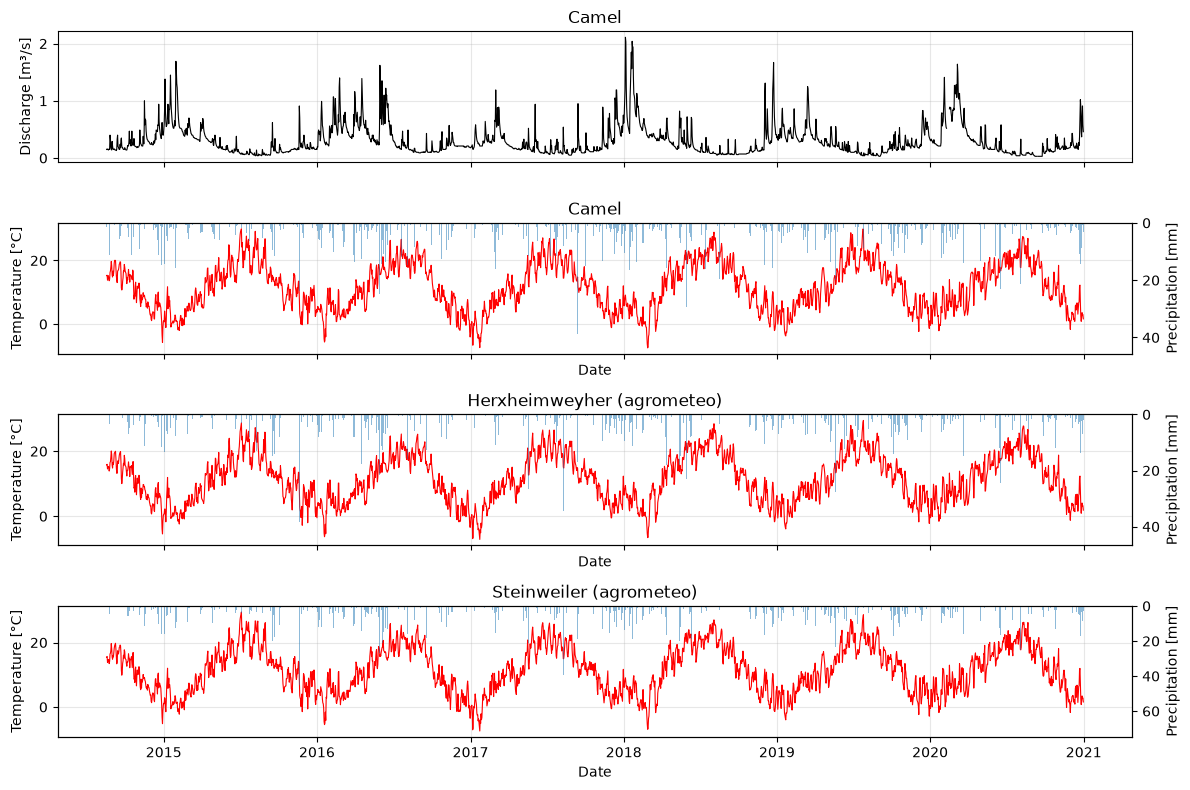

In [35]:
plot = plot_flow_precip_temp(data=data)

save_plot(plot=plot, name="daily_data_overview")

### Quality checks

In [7]:
# Question 1.1
print_data_length(data=data)

Name: discharge
Num rows of available data: 2328
Length of available data: 2327 days 00:00:00
Period: 2014-08-18 00:00:00 - 2020-12-31 00:00:00
------------------------
Name: camel
Num rows of available data: 2328
Length of available data: 2327 days 00:00:00
Period: 2014-08-18 00:00:00 - 2020-12-31 00:00:00
------------------------
Name: agro_herxheimweyher
Num rows of available data: 2328
Length of available data: 2327 days 00:00:00
Period: 2014-08-18 00:00:00 - 2020-12-31 00:00:00
------------------------
Name: agro_steinweiler
Num rows of available data: 2328
Length of available data: 2327 days 00:00:00
Period: 2014-08-18 00:00:00 - 2020-12-31 00:00:00
------------------------


In [12]:
# Question 1.3
check_missing_values(data=data)

Name: discharge
Number of NAs:
discharge_vol_obs     8
discharge_spec_obs    8
water_level_obs       3
dtype: int64
Percentage of NAs:
discharge_vol_obs     0.34
discharge_spec_obs    0.34
water_level_obs       0.13
dtype: float64%
------------------------
Name: camel
No missing values.
------------------------
Name: agro_herxheimweyher
No missing values.
------------------------
Name: agro_steinweiler
No missing values.
------------------------


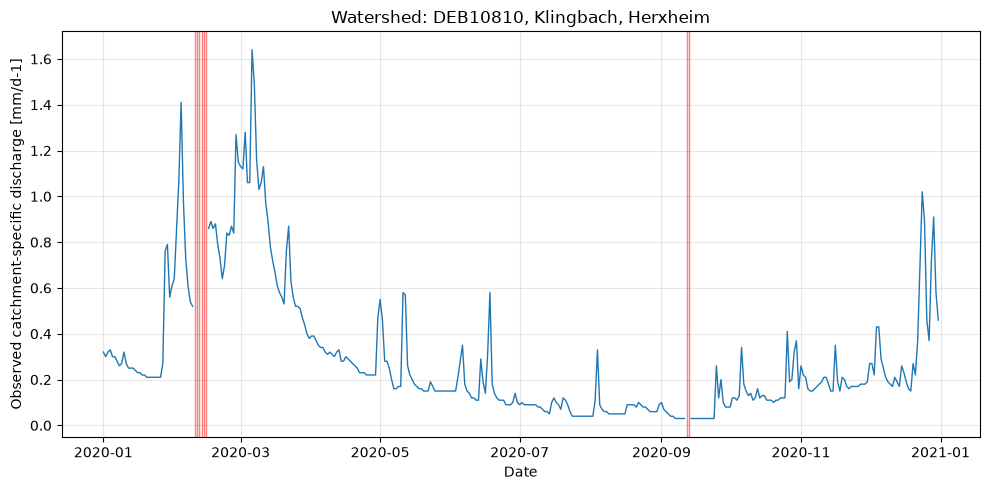

In [13]:
# Question 1.3
plot_flow_with_na(df=data.discharge, start="2020", end=None)

In [15]:
check_duplicated_dates(data=data)

Name: discharge
Duplicated dates: False
------------------------
Name: camel
Duplicated dates: False
------------------------
Name: agro_herxheimweyher
Duplicated dates: False
------------------------
Name: agro_steinweiler
Duplicated dates: False
------------------------


## 2. Catchment Description

In [23]:
from acp4.io.read_data import read_landuse_csv
from acp4.geo.io.read_data import read_catchment, read_gauge_station, create_weatherstation_points, read_dem_window
from acp4.geo.process.process_raster import expand_bbox
from acp4.geo.plot.plot import plot_watershed_stations, plot_watershed_stations_dem, plot_watershed_overview
from acp4.geo.plot.plot import plot_landuse

In [21]:
# Catchment
gdf_watershed = read_catchment(
    filepath=config.catchment_gpkg_path,
    gauge_id=config.gauge_id
    )

# Gauge station
gdf_gauge = read_gauge_station(
    filepath=config.gauge_gpkg_path,
    gauge_id=config.gauge_id
)

# Agrometeo stations
gdf_stations = create_weatherstation_points(points=config.agrometeo_points)

# DEM
bbox = expand_bbox(gdf=gdf_watershed, extent=20_000)

dem, dem_transform, dem_crs = read_dem_window(
    filepath=config.dem_asc_path,
    bbox=bbox
)

# Transform to EPSG 3857 for contextily
gdf_stations_3857 = gdf_stations.to_crs("EPSG:3857")
gdf_watershed_3857 = gdf_watershed.to_crs(crs="EPSG:3857")

assert gdf_watershed_3857.crs == gdf_stations_3857.crs

# Transform to EPSG 25832 for DEM
gdf_watershed_25832 = gdf_watershed.to_crs(dem_crs)
gdf_gauge_25832 = gdf_gauge.to_crs(dem_crs)
gdf_stations_25832= gdf_stations.to_crs(dem_crs)

assert gdf_watershed_25832.crs == gdf_gauge_25832.crs == gdf_stations_25832.crs

Catchment Area [km²]: [100.45868705]


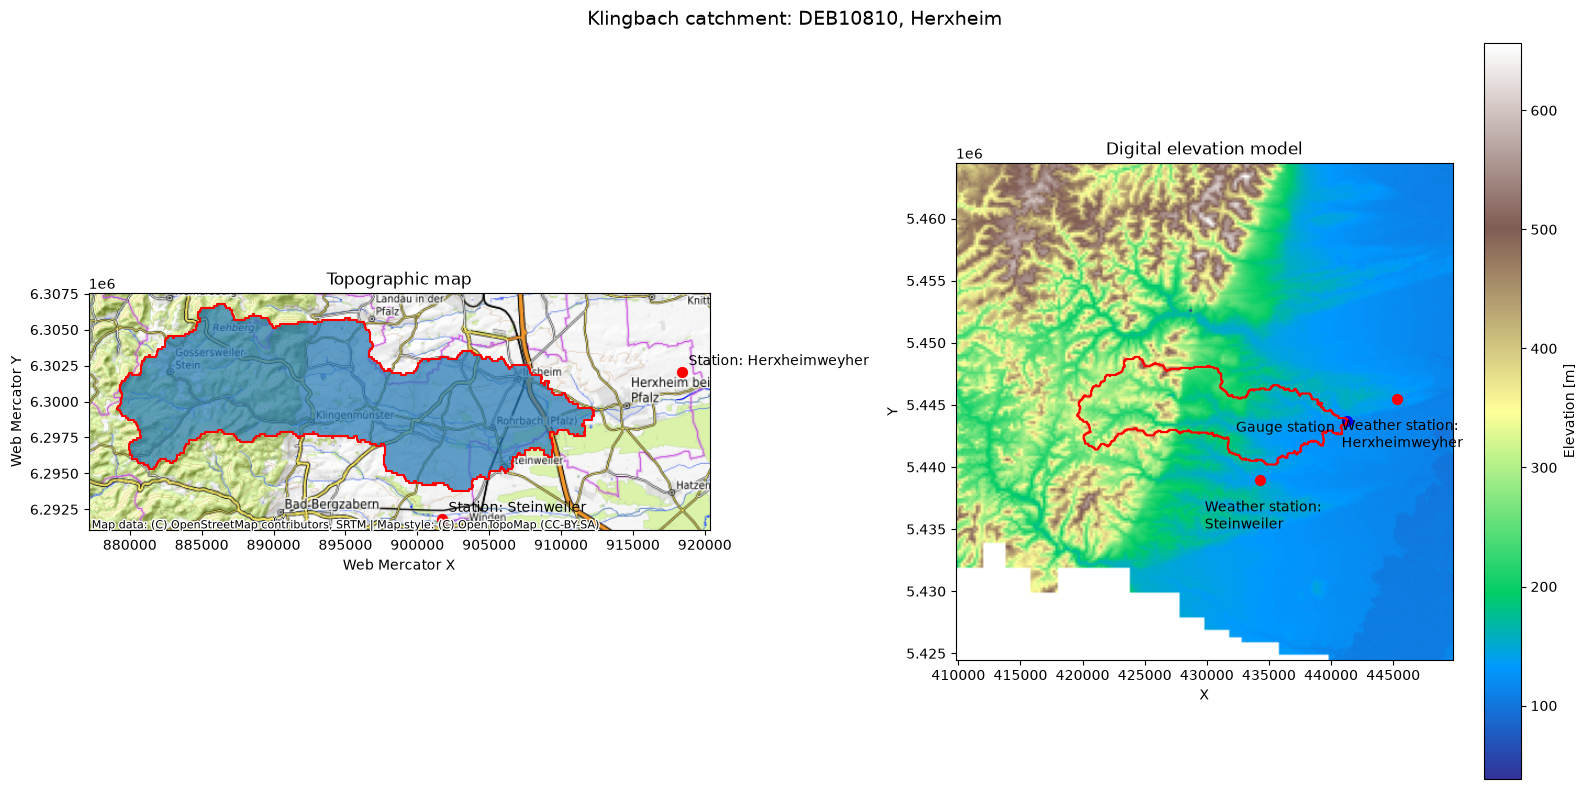

In [41]:
# 2.1 What is the geographic location of the catchment? Where are the discharge
# gauging station and the precipitation stations located?
gdf_watershed_25832_area_m2 = gdf_watershed_25832.area.to_numpy() / 1_000_000
print(f"Catchment Area [km²]: {gdf_watershed_25832_area_m2}")

# plot_watershed_stations(
#     points=gdf_stations_3857,
#     watershed=gdf_watershed_3857
# )

# plot_watershed_stations_dem(
#     points=gdf_stations_25832,
#     gauge=gdf_gauge_25832,
#     watershed=gdf_watershed_25832,
#     dem=dem,
#     dem_transform=dem_transform,
# )

plot = plot_watershed_overview(
    points=gdf_stations,
    gauge=gdf_gauge,
    watershed=gdf_watershed,
    dem=dem,
    dem_crs=dem_crs,
    dem_transform=dem_transform,
)

save_plot(plot=plot, name="catchment_overview")

In [16]:
# 2.2 Coordinates and elevation range
elevation_ravel = np.ravel(dem.data)
elevation_ravel = elevation_ravel[np.where(elevation_ravel != -9999.0)]
elevation_ravel = np.round(elevation_ravel)

print(f"Elevation range [m]: {min(elevation_ravel)} - {max(elevation_ravel)}")

Elevation range [m]: 38.0 - 656.0


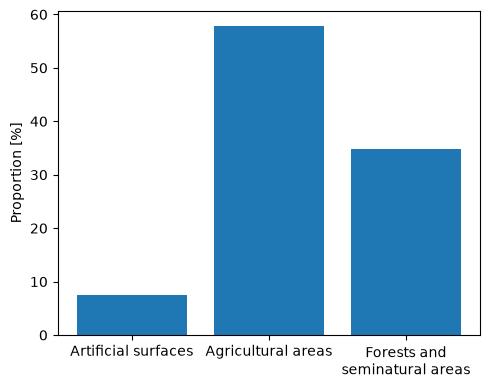

In [42]:
# 2.4 How is the land use split between agriculture, forests and artificial areas?
plot = plot_landuse(filepath=config.landcover_csv_path)
save_plot(plot=plot, name="catchment_landuse")

## 3. Climate Analysis

In [4]:
from acp4.plot.plot import (
    plot_all_monthly_temp_hum_rad,
    print_minmax_month,
    plot_both_pet_comparison
)
from acp4.processing.process_data import summarize_data
from acp4.processing.pet import calculate_hargreaves_pet

In [5]:
# 3.1 (...) Which months are the warmest and coldest?
print_minmax_month(data=data)

camel
Coldest months:
Jan

Hottest months:
Jul
---------------------

agro_herxheimweyher
Coldest months:
Jan

Hottest months:
Jul
---------------------

agro_steinweiler
Coldest months:
Jan

Hottest months:
Jul
---------------------



In [9]:
def extract_min_max_values(df: pd.DataFrame) -> None:
    for col in df.columns.to_list():
        
        if not "mean" in col[1]:
            continue
        
        col = col[0]
        
        min_idx = df[col].idxmin()["mean"]
        max_idx = df[col].idxmax()["mean"]
        
        print(f"Date: {min_idx}")
        print(f"{col.replace('_mean', '_min')}: {df.loc[min_idx, col]['mean']}")
        print("----------------------------")
        print(f"Date: {max_idx}")
        print(f"{col.replace('_mean', '_max')}: {df.loc[max_idx, col]['mean']}")
        print("============================")

summarized_data = summarize_data(df=data.camel, group_by="month")

extract_min_max_values(df=summarized_data)

Date: Apr
precipitation_min: 1.19
----------------------------
Date: Dec
precipitation_max: 2.51
Date: Jul
humidity_min: 60.78
----------------------------
Date: Dec
humidity_max: 89.01
Date: Dec
radiation_global_min: 25.2
----------------------------
Date: Jul
radiation_global_max: 236.5
Date: Jan
temperature_min: 2.72
----------------------------
Date: Jul
temperature_max: 21.4


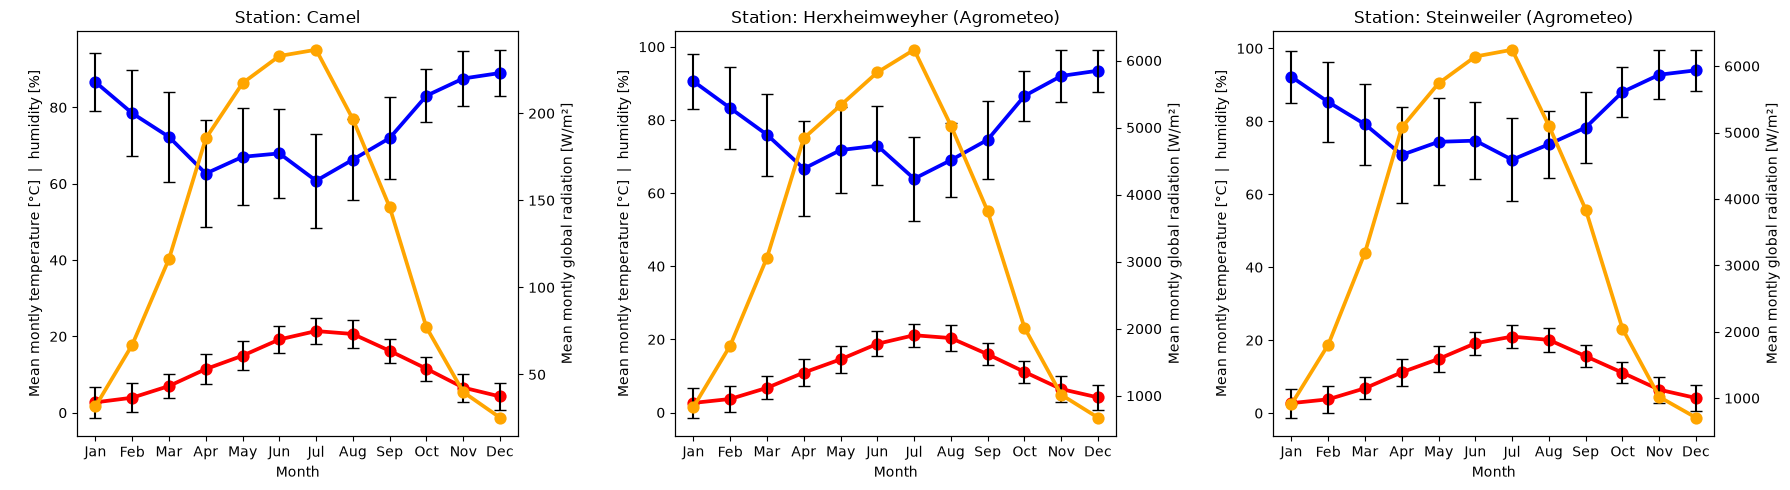

In [10]:
# 3.1 Calculate mean monthly temperature. (...) 
plot = plot_all_monthly_temp_hum_rad(data=data)
save_plot(plot=plot, name="temp_precip_rad_overview")

In [11]:
# 3.5 Calculate PET using Hargreaves equation for one of your stations (...)
df_camel = read_camel_data(
    timeseries_dir=config.timeseries_simulated_dir, 
    gauge_id=config.gauge_id
)

df_pet_herxheimweyher = calculate_hargreaves_pet(
    df=data.agro_herxheimweyher
)

df_pet_steinweiler = calculate_hargreaves_pet(
    df=data.agro_steinweiler
)

In [12]:
print(df_camel["pet_hargreaves"].quantile(q=0.95))
print(df_pet_herxheimweyher.quantile(q=0.95))
print(df_pet_steinweiler.quantile(q=0.95))

4.59
14.606827882160761
14.49521476933634


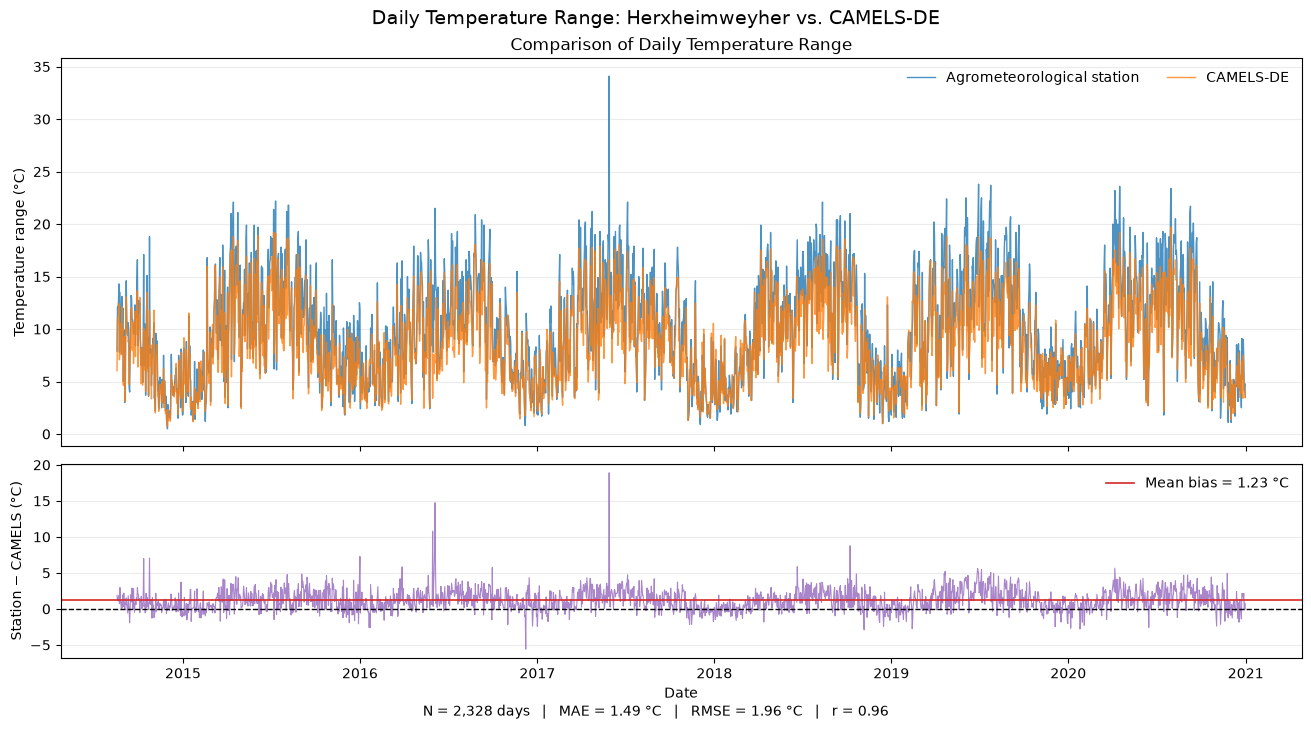

In [70]:
temp_diff_agro = (
    data.agro_herxheimweyher["temperature_max"]
    - data.agro_herxheimweyher["temperature_min"]
)

temp_diff_camel = (
    data.camel["temperature_max"]
    - data.camel["temperature_min"]
)

# Align both time series to identical dates
comparison = pd.concat(
    {
        "Agrometeorological station": temp_diff_agro,
        "CAMELS-DE": temp_diff_camel,
    },
    axis=1,
).dropna()

comparison["Difference"] = (
    comparison["Agrometeorological station"] - comparison["CAMELS-DE"]
)

# Summary statistics
bias = comparison["Difference"].mean()
mae = comparison["Difference"].abs().mean()
rmse = (comparison["Difference"].pow(2).mean()) ** 0.5
correlation = comparison.iloc[:, :2].corr().iloc[0, 1]

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(13, 7),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 1]},
    layout="constrained",
)

# Upper panel: temperature range
ax1.plot(
    comparison.index,
    comparison["Agrometeorological station"],
    label="Agrometeorological station",
    linewidth=1.0,
    alpha=0.8,
)
ax1.plot(
    comparison.index,
    comparison["CAMELS-DE"],
    label="CAMELS-DE",
    linewidth=1.0,
    alpha=0.8,
)

ax1.set_title("Comparison of Daily Temperature Range")
ax1.set_ylabel("Temperature range (°C)")
ax1.legend(frameon=False, ncols=2)
ax1.grid(axis="y", alpha=0.25)

# Lower panel: difference
ax2.plot(
    comparison.index,
    comparison["Difference"],
    color="tab:purple",
    linewidth=0.8,
    alpha=0.8,
)
ax2.axhline(0, color="black", linewidth=1, linestyle="--")
ax2.axhline(bias, color="tab:red", linewidth=1.2, linestyle="-",
            label=f"Mean bias = {bias:.2f} °C")

ax2.set_ylabel("Station − CAMELS (°C)")
ax2.set_xlabel("Date")
ax2.grid(axis="y", alpha=0.25)
ax2.legend(frameon=False)

fig.suptitle(
    "Daily Temperature Range: Herxheimweyher vs. CAMELS-DE",
    fontsize=14,
)

# Summary statistics in the figure
stats = (
    f"N = {len(comparison):,} days   |   "
    f"MAE = {mae:.2f} °C   |   "
    f"RMSE = {rmse:.2f} °C   |   "
    f"r = {correlation:.2f}"
)
fig.text(0.5, -0.015, stats, ha="center", fontsize=10)

plt.show()

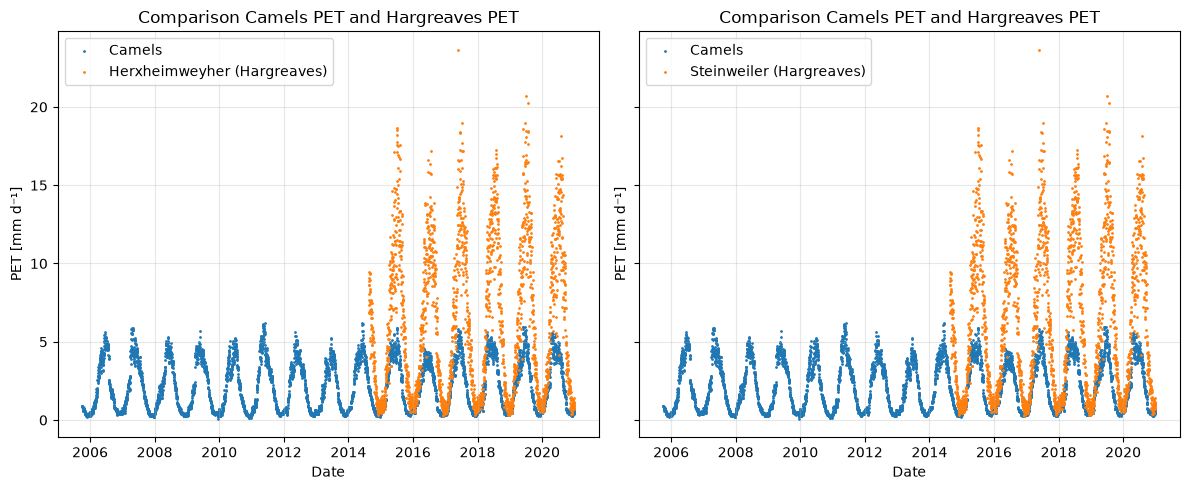

In [21]:
# 3.5 (...) and compare to the CAMELS PET value.
plot = plot_both_pet_comparison(
    camel_pet=df_camel["pet_hargreaves"].iloc[20000:],
    herxheimweyher_pet=df_pet_herxheimweyher,
    steinweiler_pet=df_pet_herxheimweyher
)

save_plot(plot=plot, name="pet_comparison")

## 4. Rainfall Analysis

In [5]:
from acp4.processing.process_data import agg_all_annually_sum, agg_all_monthly_precip_sum
from acp4.plot.plot import (
    plot_all_annual_precip_sum, 
    plot_all_monthly_precip_sum,
    plot_all_extreme_rainfall_events
)

Vieljähriger Mittelwert: 788.9 mm
https://www.dwd.de/DE/leistungen/zeitreihen/zeitreihen.html?nn=480164

In [10]:
def print_annual_mean_precip_sum(df: pd.DataFrame) -> None:
    print("Average precip sum 2016-2020:\n")
    for key, df in annual_mean_sum.items():
        print(key) 
        print("Mean: ", 
            (
                df.loc[df.index != 2015]['sum']
                .mean()
                .round(2)
            )
        )
        print("Std: ", 
            (
                df.loc[df.index != 2015]["sum"]
                .std()
                .round(2))
            )
        print("-----------------")

Average precip sum 2016-2020:

camel
Mean:  687.0
Std:  30.8
-----------------
agro_herxheimweyher
Mean:  562.65
Std:  63.52
-----------------
agro_steinweiler
Mean:  717.66
Std:  91.45
-----------------


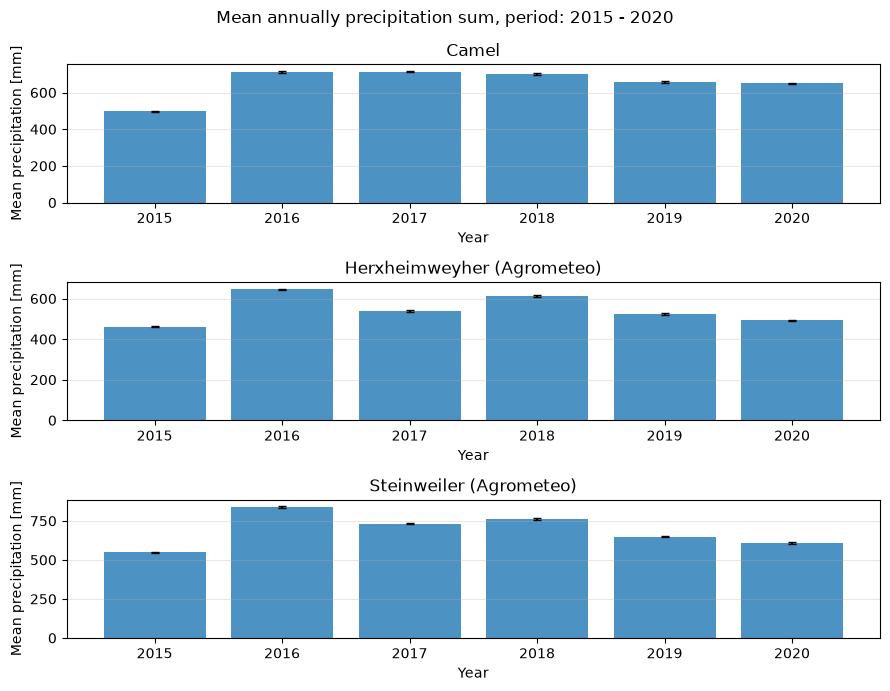

In [11]:
# 4.1 Describe the annual rainfall regime (annual mean sum, ...)
# 4.2 Plot the annual average sum of rainfall over time.
annual_mean_sum = agg_all_annually_sum(data=data)    
print_annual_mean_precip_sum(df=annual_mean_sum)

plot = plot_all_annual_precip_sum(data=annual_mean_sum)
save_plot(plot=plot, name="annual_mean_precip_sum")

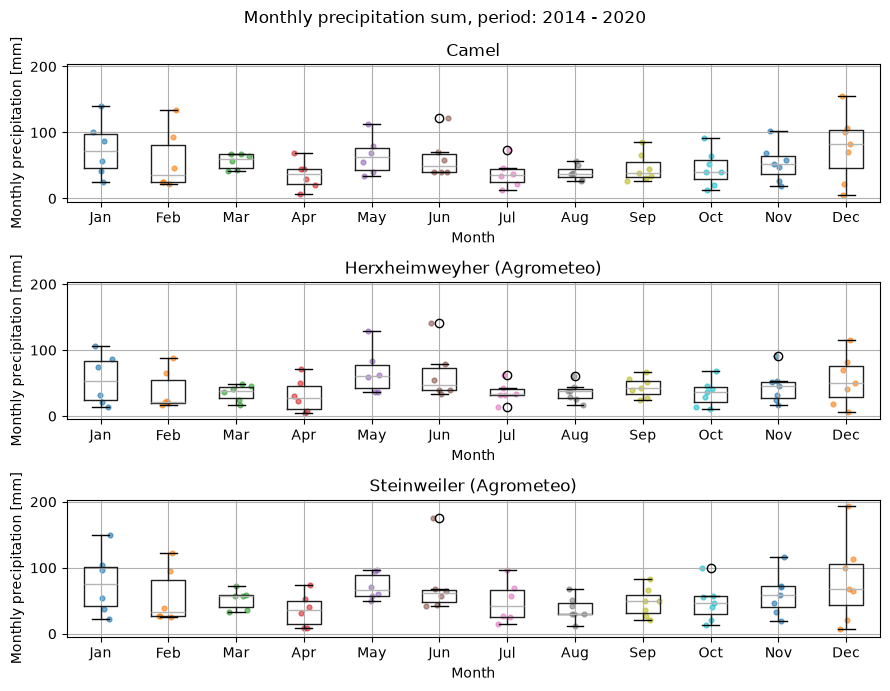

In [12]:
# 4.1 Describe the annual rainfall regime ( (...), seasonal distribution)
monthly_precip_sum = agg_all_monthly_precip_sum(data=data)

plot = plot_all_monthly_precip_sum(data=monthly_precip_sum)
save_plot(plot=plot, name="seasonal_distribution_precipitation")

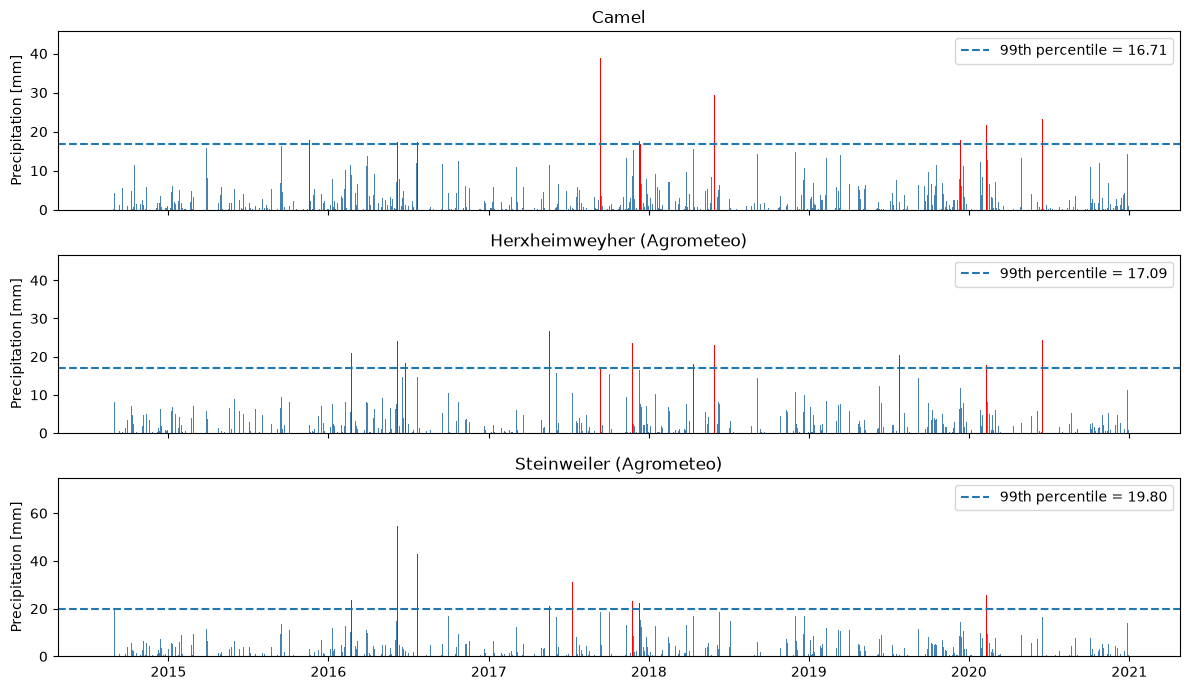

In [14]:
# 4.4 Identify extreme rainfall events (>99th percentile).
plot = plot_all_extreme_rainfall_events(data=data)
save_plot(plot=plot, name="extreme_precip_events")

## 5. Streamflow Analysis

In [159]:
import pymannkendall as mk

from acp4.processing.process_data import (
    agg_annually_discharge,
    agg_monthly_discharge_mean,
    subset_high_low_values,
    calc_longterm_runoff_coeff
)
from acp4.plot.plot import (
    plot_annual_discharge_sum,
    plot_monthly_discharge_mean,
    plot_annual_max_flow_days,
    plot_rating_curve,
    plot_annual_temperature_trend,
    plot_annual_precip_trend,
    plot_discharge_trends,
    plot_high_low_percentile_flows
)

from acp4.processing.process_data import agg_annually_discharge

In [53]:
# Note: Here i reload the data which is unaligned and therefore provides more data from the past
df_discharge, _ = read_camel_data(
    timeseries_dir=config.timeseries_dir, 
    gauge_id=config.gauge_id
)

df_discharge.dropna(inplace=True)

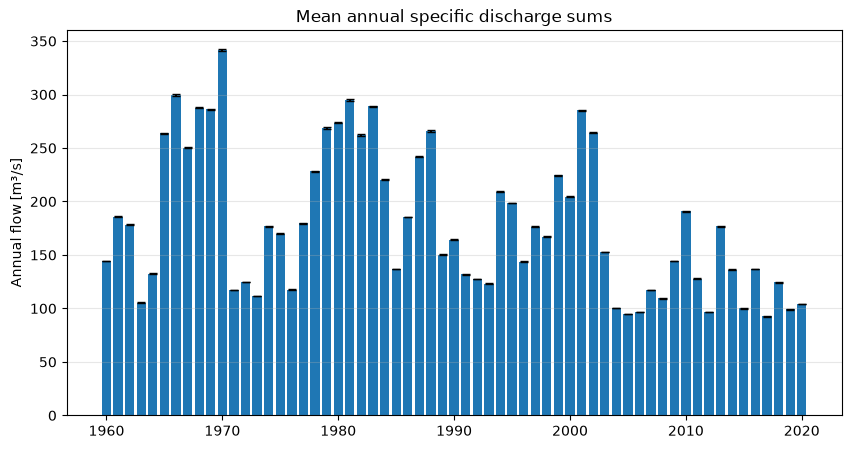

In [54]:
# 5.1. What are the average annual flows? Use specific discharge in mm/d to calculate
# average annual sums that are comparable to the annual precipitation sums.
annual_discharge_agg = agg_annually_discharge(df=df_discharge["discharge_spec_obs"])

plot = plot_annual_discharge_sum(annual_discharge_agg)
save_plot(plot=plot, name="mean_annual_flows")

In [55]:
# 5.2. What is the mean daily flow, as well as the highest and lowest recorded flows?
# [both for m3/s and observed water level]3
print("Specific Discharge [m3/s]:")
print(f"Mean daily flow: {df_discharge['discharge_vol_obs'].mean().round(3)}")
print(f"Min daily flow: {df_discharge['discharge_vol_obs'].min()}")
print(f"Max daily flow: {df_discharge['discharge_vol_obs'].max()}")

print("-----------------------------")
print("Specific Discharge [mm/d]:")
print(f"Mean daily flow: {df_discharge['discharge_spec_obs'].mean().round(3)}")
print(f"Min daily flow: {df_discharge['discharge_spec_obs'].min()}")
print(f"Max daily flow: {df_discharge['discharge_spec_obs'].max()}")

print("-----------------------------")
print("Water level [cm]:")
print(f"Mean daily waterlevel: {df_discharge['water_level_obs'].mean().round(2)}")
print(f"Min daily waterlevel: {df_discharge['water_level_obs'].min()}")
print(f"Max daily waterlevel: {df_discharge['water_level_obs'].max()}")

Specific Discharge [m3/s]:
Mean daily flow: 0.57
Min daily flow: 0.02
Max daily flow: 6.58
-----------------------------
Specific Discharge [mm/d]:
Mean daily flow: 0.49
Min daily flow: 0.02
Max daily flow: 5.66
-----------------------------
Water level [cm]:
Mean daily waterlevel: 29.36
Min daily waterlevel: 1.0
Max daily waterlevel: 134.0


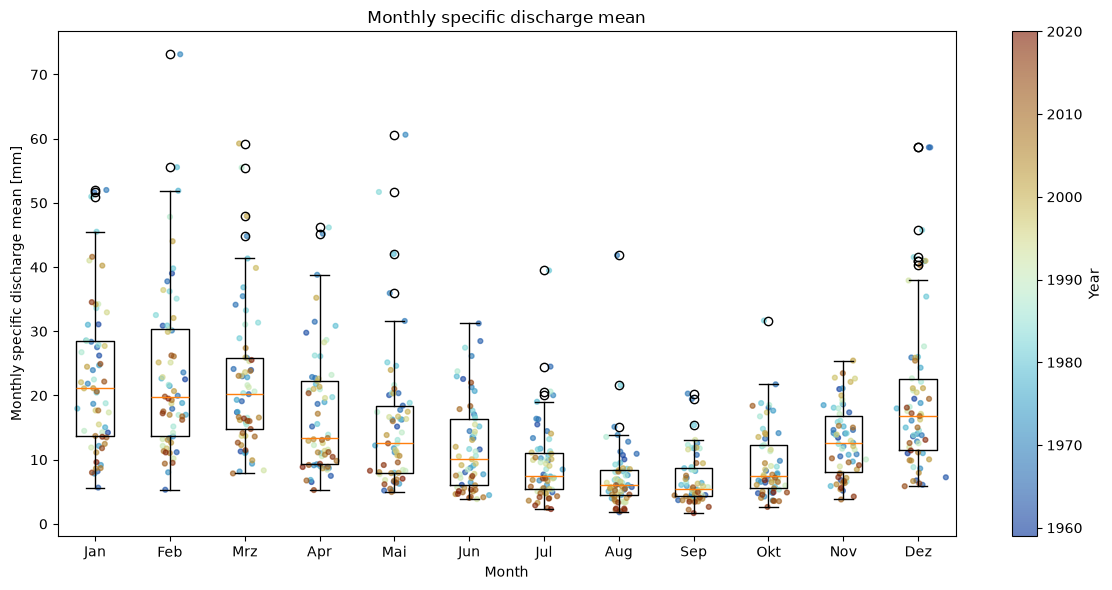

In [57]:
# 5.3. Calculate mean monthly flow. How does streamflow vary throughout the year?
# Does rainfall seasonality correspond to streamflow seasonality? If not, what
# processes could explain the differences?
monthly_discharge_mean = agg_monthly_discharge_mean(df=df_discharge['discharge_spec_obs'])

plot = plot_monthly_discharge_mean(df=monthly_discharge_mean)
save_plot(plot=plot, name="mean_monthly_flow")

In [58]:
def count_extreme_precip_events_by_month(df: pd.DataFrame) -> pd.DataFrame:
    df = df.dropna()
    
    annual = (
        df
        .groupby(df.index.year)
        .agg(max="max")
    )

    annual["max_date"] = df.groupby(df.index.year).idxmax()

    annual = annual[["max_date", "max"]]
    annual["month"] = annual["max_date"].dt.month
    annual = annual[["month", "max"]]
    
    annual = (
        annual
        .groupby("month")
        .count()
    )

    return annual


from matplotlib.patches import Patch


def plot_extreme_events_by_month(df: pd.DataFrame) -> plt.Figure:
    seasons = {
        12: "Winter", 1: "Winter", 2: "Winter",
        3: "Spring", 4: "Spring", 5: "Spring",
        6: "Summer", 7: "Summer", 8: "Summer",
        9: "Autumn", 10: "Autumn", 11: "Autumn",
    }

    season_colors = {
        "Winter": "skyblue",
        "Spring": "lightgreen",
        "Summer": "gold",
        "Autumn": "sandybrown",
    }

    bar_colors = [
        season_colors[seasons[month]]
        for month in df.index
    ]

    fig, ax = plt.subplots()

    ax.bar(
        df.index,
        df["max"],
        color=bar_colors,
    )

    ax.set_xticks(range(1, 13))
    ax.set_xticklabels([
        "Jan", "Feb", "Mar", "Apr", "May", "Jun",
        "Jul", "Aug", "Sep", "Oct", "Nov", "Dec",
    ])

    ax.set_xlabel("Month")
    ax.set_ylabel("Number of events")
    ax.set_title("Number of annual maximum discharge events by month")
    ax.grid(axis="y", alpha=0.3)

    legend_handles = [
        Patch(color=color, label=season)
        for season, color in season_colors.items()
    ]

    ax.legend(handles=legend_handles, title="Season")

    return fig

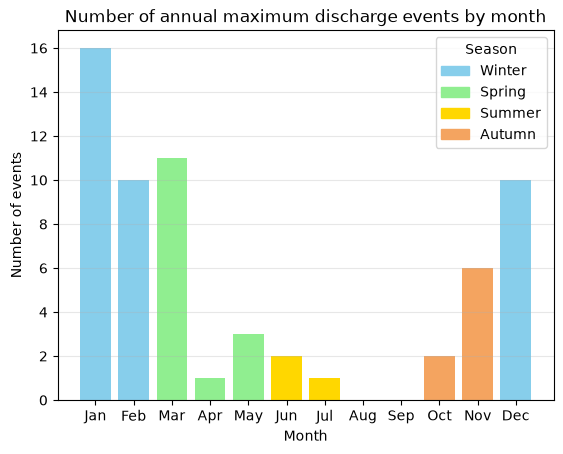

In [59]:
# 5.4 Identify annual maximum flow days.
monthly_precip_events_count = count_extreme_precip_events_by_month(
    df=df_discharge['discharge_spec_obs']
)

plot = plot_extreme_events_by_month(df=monthly_precip_events_count)
save_plot(plot=plot, name="events_by_month")

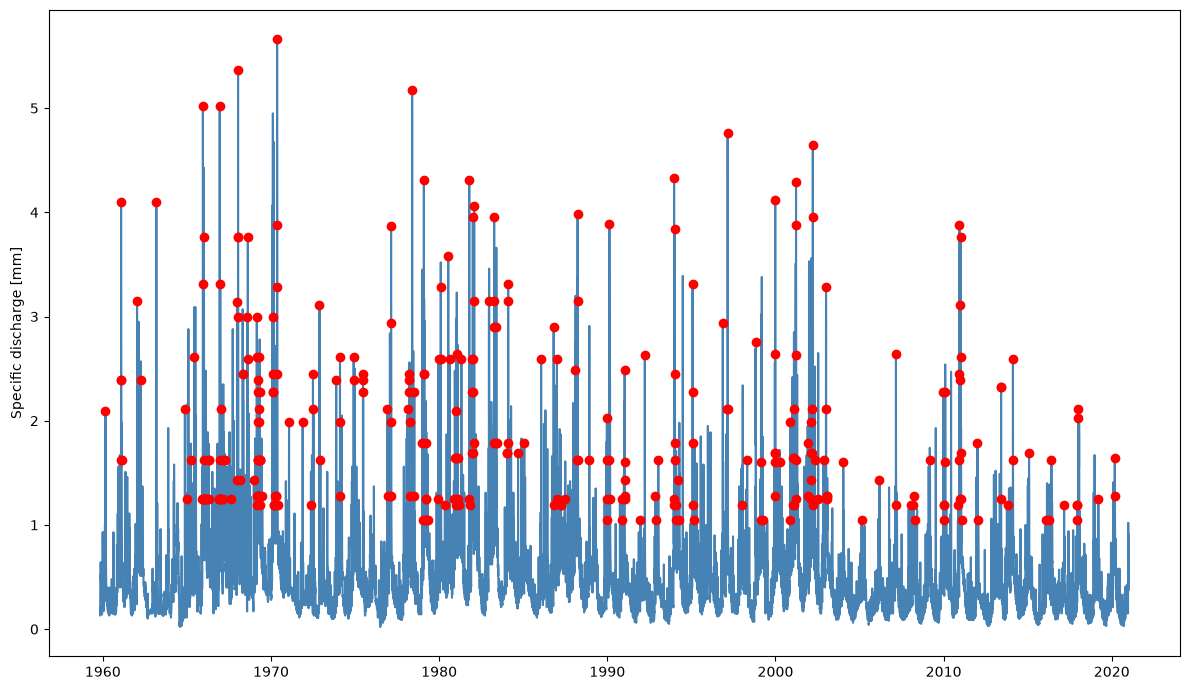

In [62]:
# 5.4 Identify annual maximum flow days.
plot = plot_annual_max_flow_days(
    df=df_discharge['discharge_spec_obs'], 
    max_flows=annual_discharge_agg['max']
)

save_plot(plot=plot, name="annual_max_flow_days")

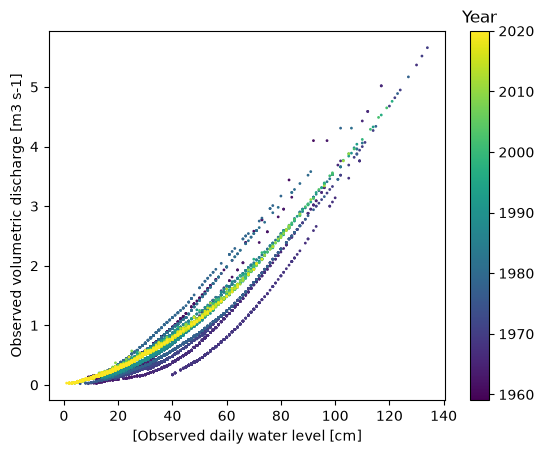

In [68]:
# 5.5. Plot the stage discharge relationship.
plot = plot_rating_curve(df=df_discharge)
save_plot(plot=plot, name="rating_curve")

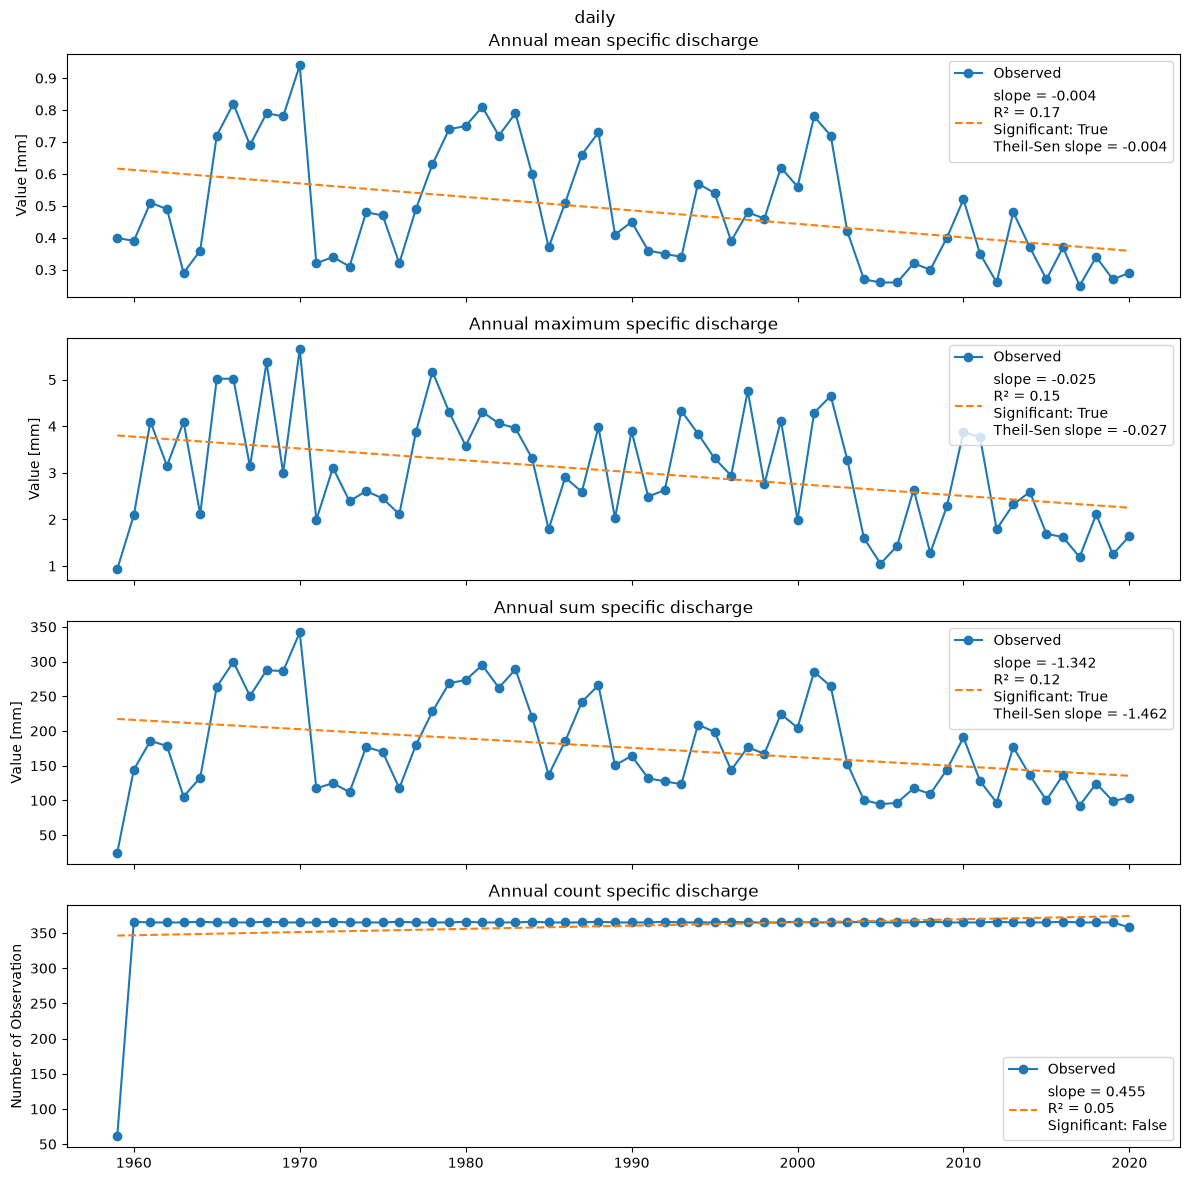

c:\Users\Administrator\Desktop\Uni Landau\Master\4. Semester\ACP4\ACP4\.venv\Lib\site-packages\pymannkendall\pymannkendall.py:60: RuntimeWarning: invalid value encountered in divide
  return acov[:nlags+1]/acov[0]


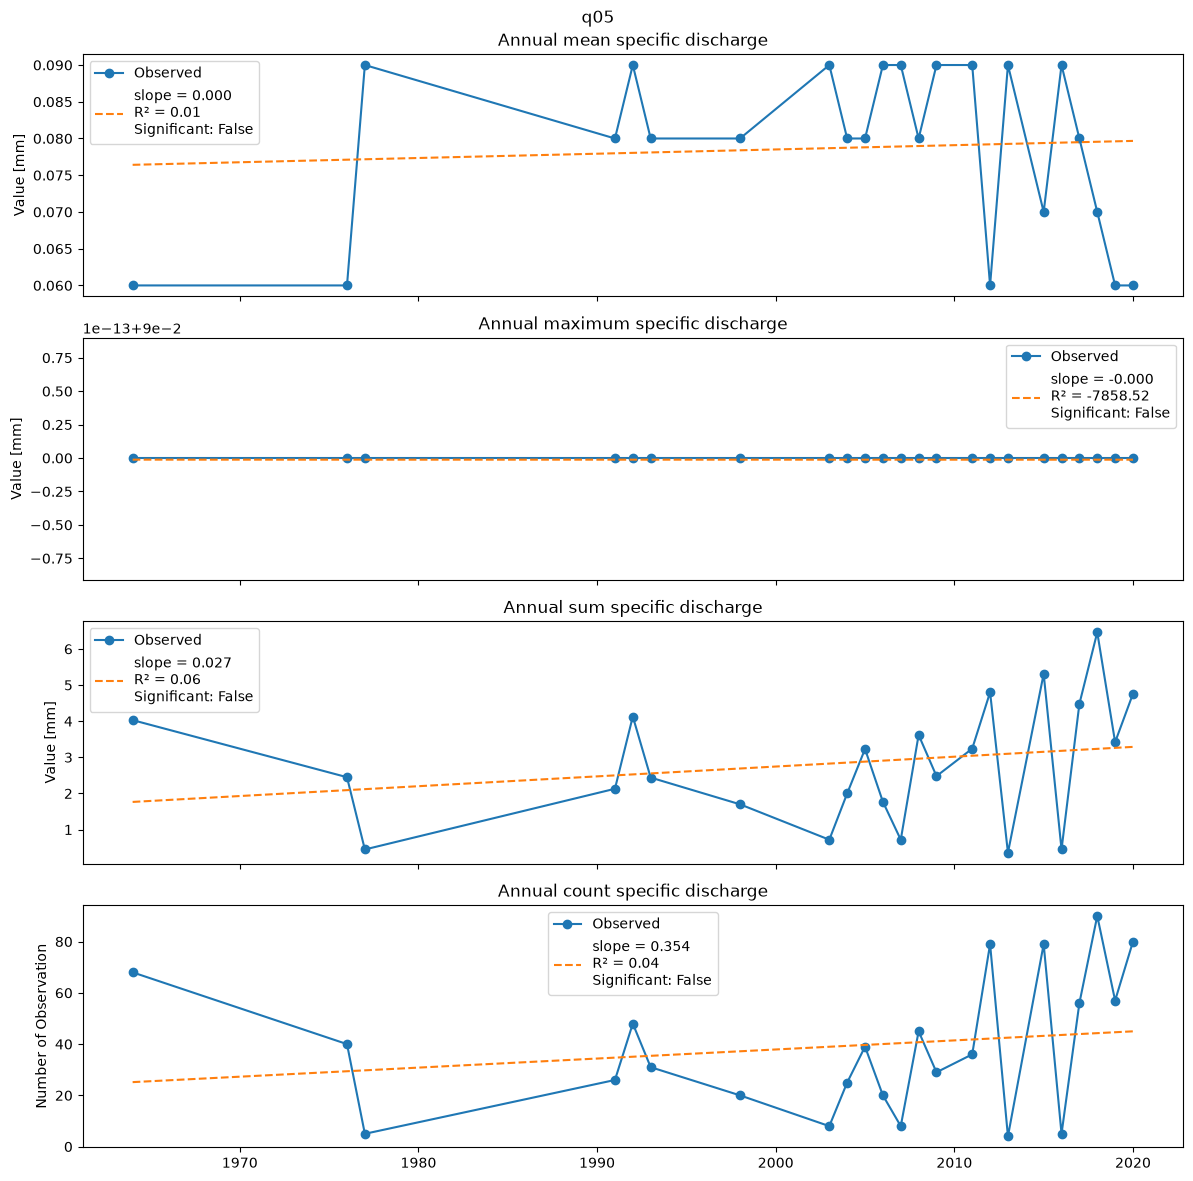

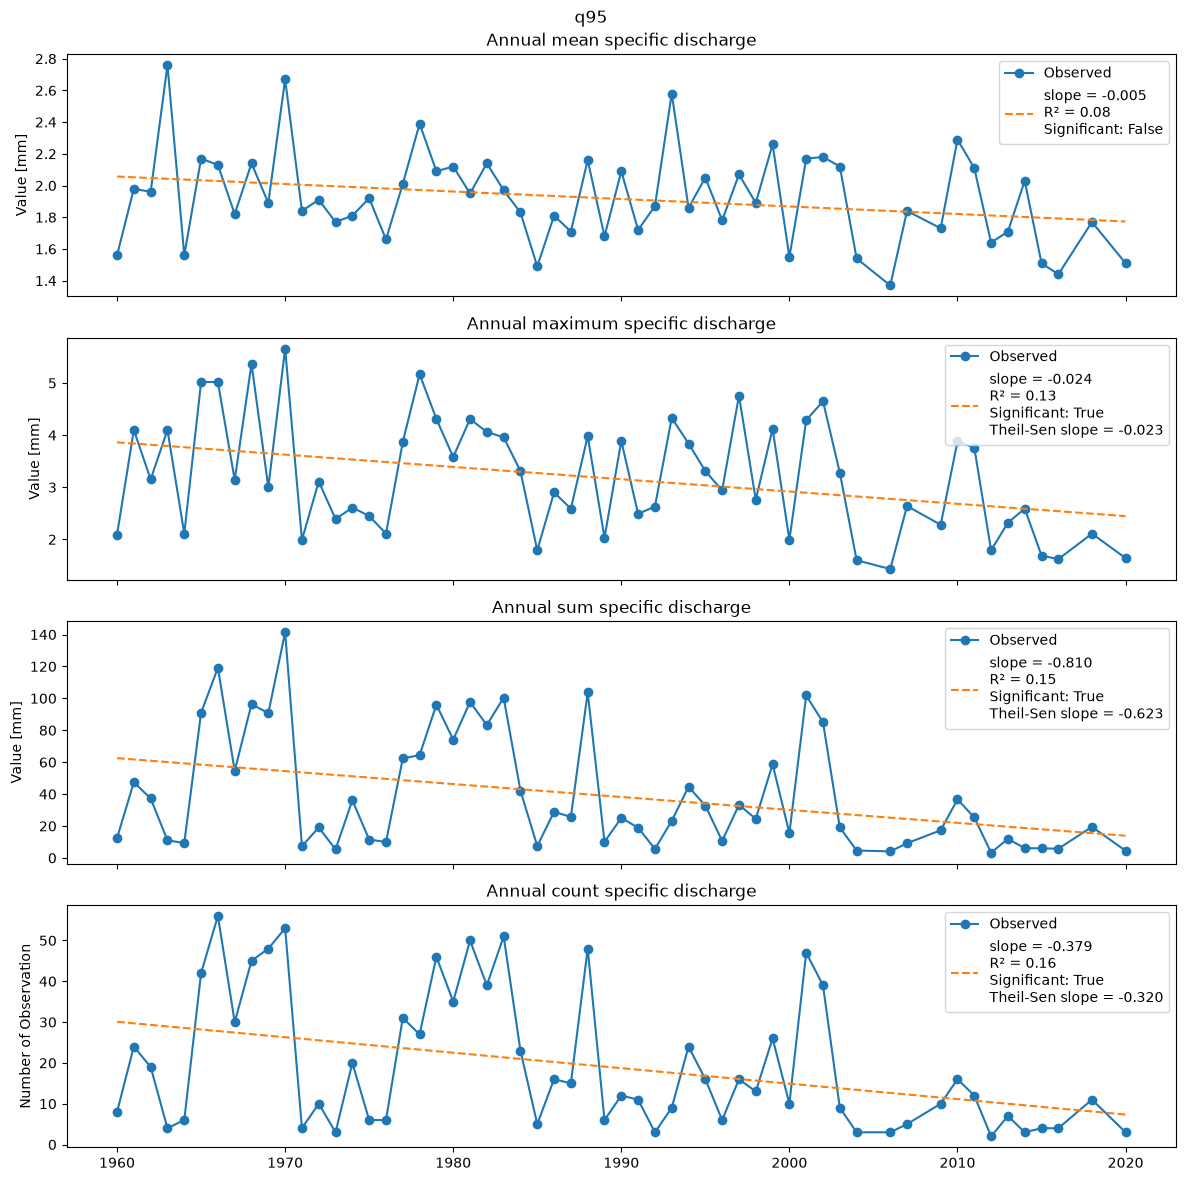

In [73]:
# 5.6. Is there a significant trend in the daily flow or in the flows above the 95th (Q95,
# high flow) or below the 5th percentile (Q5, low flow)?
subset = subset_high_low_values(df=df_discharge['discharge_spec_obs'])

discharges = {
    "daily": df_discharge['discharge_spec_obs'],
    "q05": subset["Q05"],
    "q95": subset["Q95"],
}

annually_discharge_agg = {}

for key, df in discharges.items():
    aggregated = agg_annually_discharge(df=df, complete_years_only=False)
    aggregated = aggregated.dropna()

    annually_discharge_agg[key] = aggregated


for key, df in annually_discharge_agg.items():
    plot = plot_discharge_trends(df=df, suptitle=key)
    
    save_plot(plot=plot, name=f"discharge_trend_{key}")

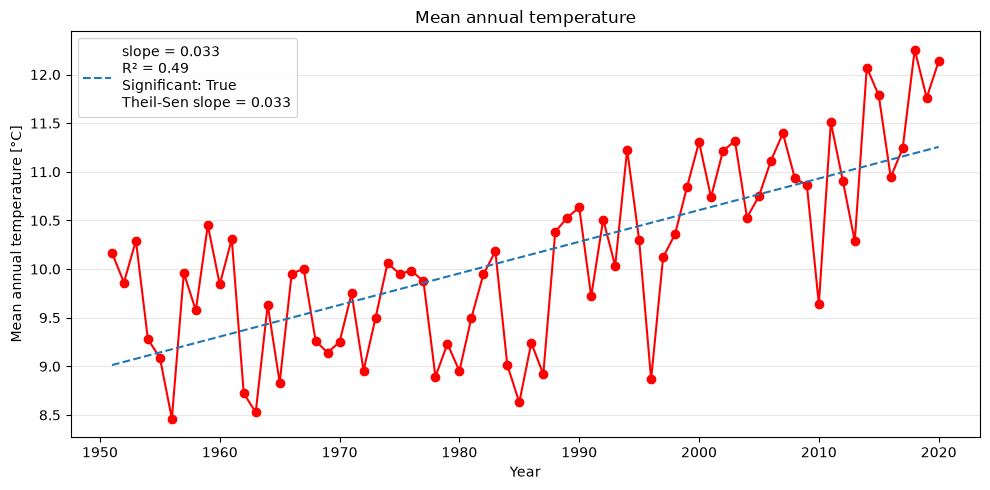

In [ ]:
# If trends are detected in high or low flows, discuss whether they are consistent
# with observed changes in rainfall or catchment characteristics
df = df_camel['temperature_mean']
df = (
    df
    .groupby(df.index.year)
    .mean()
)

df = df.to_frame().reset_index()

plot = plot_annual_temperature(df=df)
save_plot(plot=plot, name="annual_temperature_trend")

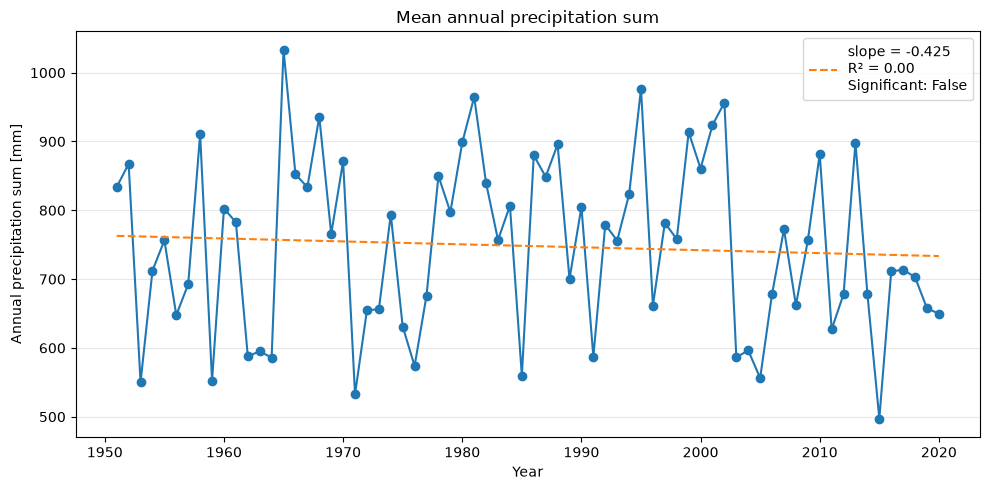

In [ ]:
# If trends are detected in high or low flows, discuss whether they are consistent
# with observed changes in rainfall or catchment characteristics
df = df_camel['precipitation_mean']

df = (
    df
    .groupby(df.index.year)
    .sum()
)

df = df.to_frame().reset_index()

plot = plot_annual_precip_trend(df=df)

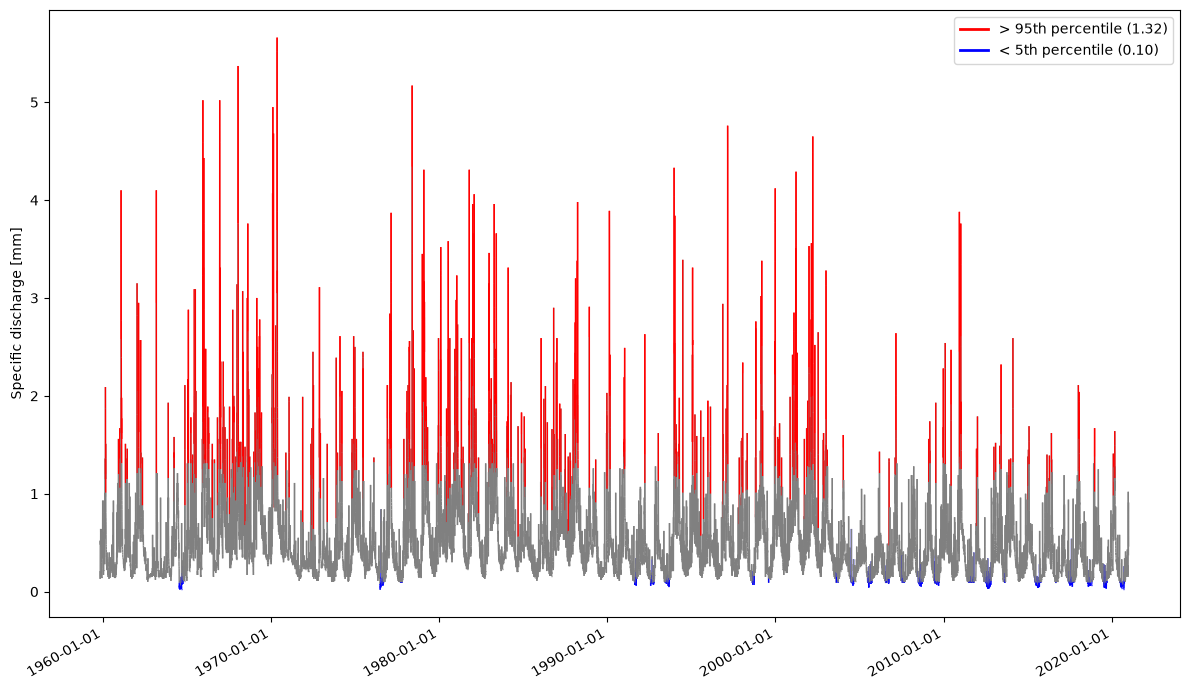

In [161]:
plot = plot_high_low_percentile_flows(df=df_discharge['discharge_spec_obs'])
save_plot(plot=plot, name="high_low_percentiles_discharge_overview")

In [164]:
# 5.7. Calculate the long-term runoff coefficient for your catchment (...).
calc_longterm_runoff_coeff(
    discharge=data.discharge["discharge_spec_obs"],
    precipitation=data.camel["precipitation_mean"]
)

Long-term runoff ratio: 0.167


np.float64(0.167)

## 6. Water Balance

In [168]:
df_camel_sim = read_camel_data(
    timeseries_dir=config.timeseries_simulated_dir, 
    gauge_id=config.gauge_id
)

In [182]:
# P = AET + Q

df = pd.concat(
    objs=[
        df_discharge["discharge_spec_obs"], 
        df_camel["precipitation_mean"],
        df_camel_sim["pet_hargreaves"],
    ],
    axis=1,
    join="inner"
)

df = (
    df
    .groupby(df.index.year)
    .agg(
        discharge_sum=("discharge_spec_obs", "sum"),
        precipitation_sum=("precipitation_mean", "sum"),
        pet_simulated_sum=("pet_hargreaves", "sum"),
    )
    .round(3)
)


df["AET"] = (df["precipitation_sum"] - df["discharge_sum"]).round(2)

print("Annual mean: ")
print(df)
print("----------------------\n")
print("Long-term annual mean:")
print(df.mean().round(2))

Annual mean: 
      discharge_sum  precipitation_sum  pet_simulated_sum     AET
date                                                             
1959          24.42             107.17              22.13   82.75
1960         144.21             802.50             741.69  658.29
1961         185.75             782.68             755.34  596.93
1962         178.35             588.05             729.96  409.70
1963         105.45             594.93             741.45  489.48
...             ...                ...                ...     ...
2016         136.69             711.16             730.73  574.47
2017          92.47             713.66             818.86  621.19
2018         124.28             702.80             856.92  578.52
2019          99.13             657.52             843.35  558.39
2020         104.01             611.75             855.62  507.74

[62 rows x 4 columns]
----------------------

Long-term annual mean:
discharge_sum        176.38
precipitation_sum    740.61
pe

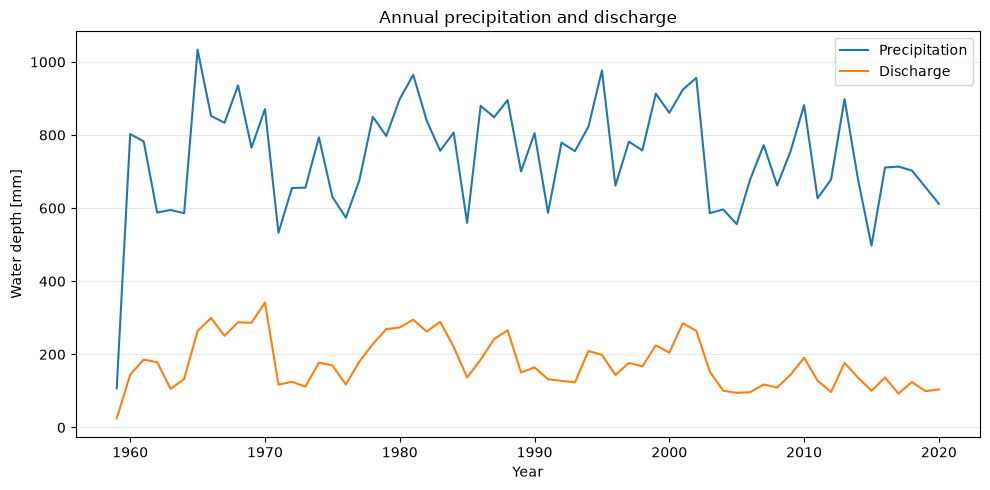

In [181]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    df.index,
    df["precipitation_sum"],
    label="Precipitation",
)
ax.plot(
    df.index,
    df["discharge_sum"],
    label="Discharge",
)

ax.set_xlabel("Year")
ax.set_ylabel("Water depth [mm]")
ax.set_title("Annual precipitation and discharge")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

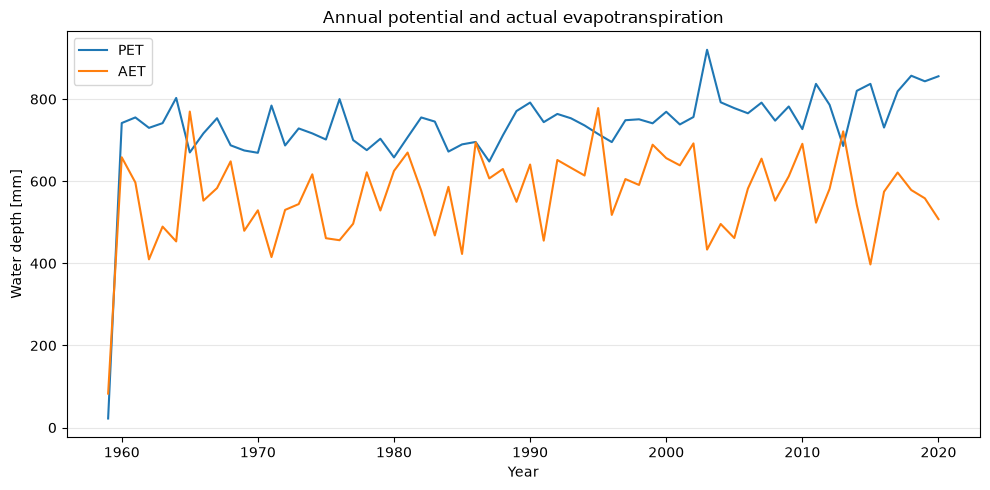

In [179]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    df.index,
    df["pet_simulated_sum"],
    label="PET",
)
ax.plot(
    df.index,
    df["AET"],
    label="AET",
)

ax.set_xlabel("Year")
ax.set_ylabel("Water depth [mm]")
ax.set_title("Annual potential and actual evapotranspiration")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

### Bug in pymannkendall.py, line 189, seasonal_sens_slope()

Maybe implementation from R is further step to get more result parmas:
https://github.com/cran/trend/blob/master/R/sens.slope.R

In [61]:
def __sens_estimator(x):
    idx = 0
    n = len(x)
    d = np.ones(int(n*(n-1)/2))

    for i in range(n-1):
        j = np.arange(i+1,n)
        d[idx : idx + len(j)] = (x[j] - x[i]) / (j - i)
        idx = idx + len(j)
        
    return d

def __preprocessing(x):
    x = np.asarray(x).astype(float)
    dim = x.ndim
    
    if dim == 1:
        c = 1
        
    elif dim == 2:
        (n, c) = x.shape
        
        if c == 1:
            dim = 1
            x = x.flatten()
         
    else:
        print('Please check your dataset.')
        
    return x, c

In [ ]:
x_old = annually_discharge_agg['max']
period=12

x, c = __preprocessing(x=x_old)
n = len(x)

print(x_old.shape)
print(x.shape)

if x.ndim == 1:
    if np.mod(n,period) != 0:
        x = np.pad(x,(0,period - np.mod(n,period)), 'constant', constant_values=(np.nan,))

    x = x.reshape(int(len(x)/period),period)

print(x_old.shape)
print(x.shape)

result_old = np.median(np.arange(x_old.size)[~np.isnan(x_old.to_numpy().flatten())])
result_new = np.median(np.arange(x.size)[~np.isnan(x.flatten())])

print(result_old)
print(result_new)